# Simulator models: what was learned, and how far to trust it

The pandemic simulator is an age-structured SEIR engine whose country-specific settings come from models trained on 2020–2023 data. This notebook reviews each model and then tests the whole simulator on data it never saw.

| | Model | Technique |
|---|---|---|
| M1 | Lockdowns and Rt | Panel regression with country fixed effects |
| M2 | Engine calibration | Per-country MAP fit, shared parameters by profile likelihood |
| M3 | Country multipliers from features | Ridge regression (gradient boosting as benchmark) |
| M4 | Vaccine rollout | Logistic curve fits, then ridge |
| M5 | Death reporting | Ridge on reported vs excess deaths |
| M6 | Wave severity | Multinomial logistic regression (gradient boosting as benchmark) |
| M7 | Country archetypes | k-means + PCA |

Design and sources: [`docs/simulator/RESEARCH.md`](../docs/simulator/RESEARCH.md).

In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from covid_pipeline.config import SIM_CALIBRATION_PATH, SIM_VALIDATION_PATH, SIM_WAVES_PATH, SIMULATOR_METRICS_PATH, SIMULATOR_MODEL_PATH, COUNTRY_PROFILE_PATH

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3})
metrics = json.loads(SIMULATOR_METRICS_PATH.read_text())
model = json.loads(SIMULATOR_MODEL_PATH.read_text())
profile = pd.read_parquet(COUNTRY_PROFILE_PATH).set_index("iso_code")
names = profile["location"]
cal = metrics["m2_calibration"]
print(f"Trained {metrics['trained_at']} in {metrics['runtime_seconds']:.0f}s; {cal['countries']} countries calibrated")

Trained 2026-10-05T01:28:11+00:00 in 757s; 137 countries calibrated


## M1 and M2: how much do lockdowns cut transmission?

Three estimates of the transmission reduction at stringency 80 (a strict lockdown):

* **Rt panel (M1)**: within-country regression of case-based Rt on stringency two weeks earlier. Governments tightened when Rt was high, and case-based Rt is noisy, so this is biased toward zero.
* **Deaths-based calibration (M2)**: the engine replays each country's 2020 with its observed stringency; the shared coefficient is the one that best explains deaths across all countries (Flaxman-style).
* **Literature**: Brauner et al. 2021 (all measures combined, 41 countries) and Flaxman et al. 2020 (lockdown, 11 European countries).

The simulator uses the deaths-based estimate. M1 supplies how the effect fades over time, how it varies with age structure, and when transmission peaks in the year.

Fatigue: the 2021H1 effect is 80% of the 2020 effect. Adherence: +1 SD in share aged 65+ changes the effect by +71%.


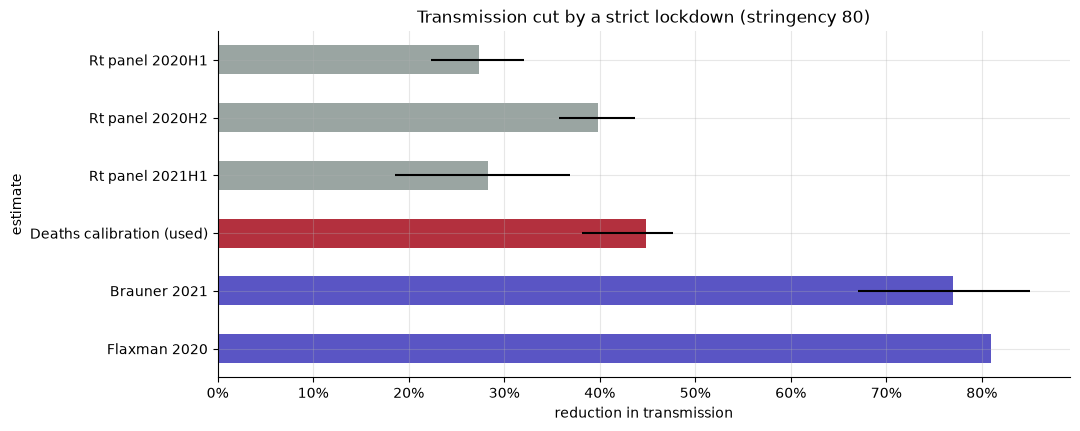

In [2]:
npi = metrics["m1_lockdown_panel"]
rows = [(f"Rt panel {p}", 1 - np.exp(8 * v["coef_per_10"]), 1 - np.exp(8 * v["ci95"][1]), 1 - np.exp(8 * v["ci95"][0])) for p, v in npi["periods"].items()]
lo, hi = cal["reduction_at_80_90ci"]
rows += [("Deaths calibration (used)", cal["reduction_at_80"], lo, hi), ("Brauner 2021", 0.77, 0.67, 0.85), ("Flaxman 2020", 0.81, np.nan, np.nan)]
est = pd.DataFrame(rows, columns=["estimate", "reduction", "lo", "hi"]).set_index("estimate")
ax = est["reduction"].plot.barh(color=["#9aa5a2"] * 3 + ["#b3303e", "#5a55c4", "#5a55c4"], xerr=[est["reduction"] - est["lo"], est["hi"] - est["reduction"]])
ax.invert_yaxis(); ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.set(title="Transmission cut by a strict lockdown (stringency 80)", xlabel="reduction in transmission")
print(f"Fatigue: the 2021H1 effect is {npi['fatigue_ratio']:.0%} of the 2020 effect. "
      f"Adherence: +1 SD in share aged 65+ changes the effect by {npi['adherence_per_sd_65_plus']:+.0%}.")

### Seasonality and the calibration surface

Three parameters are shared by every country and chosen together: the lockdown coefficient, the **awareness** threshold (the 7-day average of reported deaths per million per day at which people halve their contacts) and the **seasonal amplitude** at latitudes of 40° or more. M1 supplies the timing of the seasonal peak.

Seasonality fades from full strength at 40° to nothing at the edge of the tropics (23.5°). **This weighting was revised once after seeing held-out data.** The first version ramped up from the equator, which gave India, Bangladesh and Ethiopia winter waves they never had. Because the choice was made after looking at the holdout, the holdout scores below are slightly optimistic.

The left panel slices the misfit surface at the best seasonal amplitude. The right panel compares the seasonal effect with the Rt panel and with Gavenčiak et al. (2022), who estimated R falls 42% (95% CI 25–53%) from winter to summer across 143 European regions.

Best: lockdown 45% at stringency 80; awareness threshold 2.7547 (90% CI [2.0058, 4.022]); seasonal amplitude 0.3884 (90% CI [0.3255, 0.5]); transmission peaks on day 2 of the year in the north.


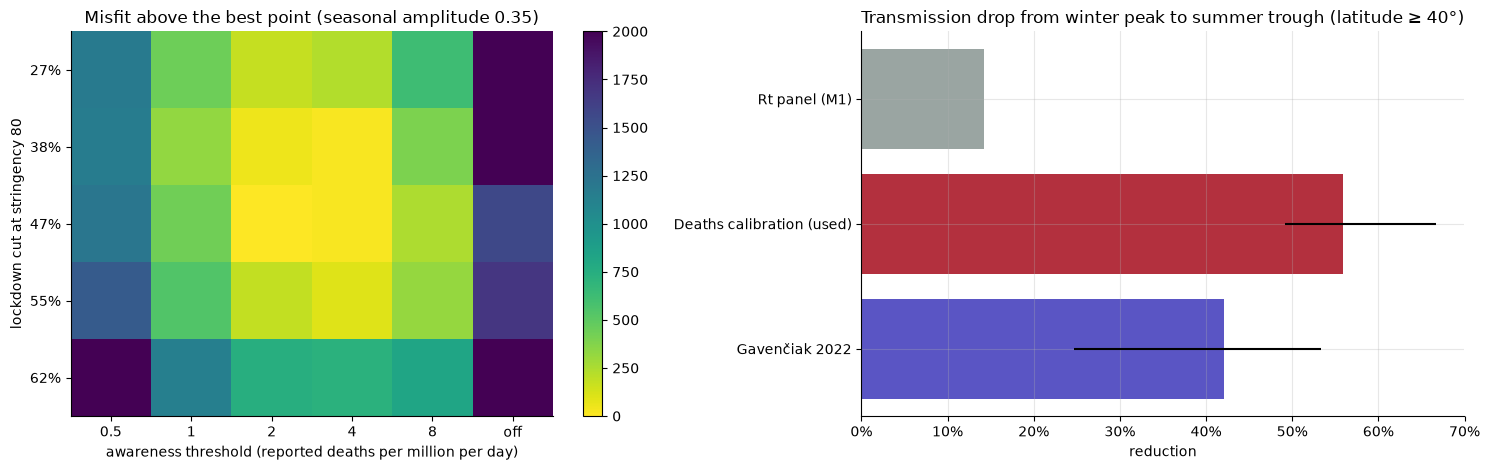

In [3]:
surface = np.array(cal["surface"]["total_misfit"])  # (lockdown, awareness, seasonality)
seasons = np.array(cal["surface"]["seasonality"])
k = int(np.abs(seasons - cal["seasonality"]).argmin())
grid = pd.DataFrame(surface[:, :, k], index=[f"{1 - np.exp(80 * c):.0%}" for c in cal["surface"]["npi_coef"]],
                    columns=[("off" if a is None else f"{a:g}") for a in cal["surface"]["awareness_deaths_pm"]])
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
im = axes[0].imshow(grid - surface.min(), cmap="viridis_r", aspect="auto", vmax=2000)
axes[0].set_xticks(range(grid.shape[1]), grid.columns); axes[0].set_yticks(range(grid.shape[0]), grid.index)
axes[0].set(xlabel="awareness threshold (reported deaths per million per day)", ylabel="lockdown cut at stringency 80",
            title=f"Misfit above the best point (seasonal amplitude {seasons[k]:g})"); axes[0].grid(False); plt.colorbar(im, ax=axes[0])

season = metrics["m1_lockdown_panel"]["seasonality"]
ours = cal["winter_to_summer_reduction"]
lo, hi = [2 * a / (1 + a) for a in cal["seasonality_90ci"]]
bench = pd.DataFrame({"reduction": [season["winter_to_summer_reduction"], ours, 0.421], "lo": [np.nan, lo, 0.247], "hi": [np.nan, hi, 0.534]},
                     index=["Rt panel (M1)", "Deaths calibration (used)", "Gavenčiak 2022"])
axes[1].barh(bench.index, bench["reduction"], color=["#9aa5a2", "#b3303e", "#5a55c4"],
             xerr=[(bench["reduction"] - bench["lo"]).fillna(0), (bench["hi"] - bench["reduction"]).fillna(0)])
axes[1].invert_yaxis(); axes[1].xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
axes[1].set(title="Transmission drop from winter peak to summer trough (latitude ≥ 40°)", xlabel="reduction")
fig.tight_layout()
print(f"Best: lockdown {cal['reduction_at_80']:.0%} at stringency 80; awareness threshold {cal['awareness_deaths_pm']} "
      f"(90% CI {cal['awareness_deaths_pm_90ci']}); seasonal amplitude {cal['seasonality']} (90% CI {cal['seasonality_90ci']}); "
      f"transmission peaks on day {cal['season_peak_day_north']:.0f} of the year in the north.")

### Example fits: 2020 replayed with each country's own parameters

Observed deaths are scaled up by the country's estimated reporting share (M5), so the engine is fitted to an estimate of true deaths.

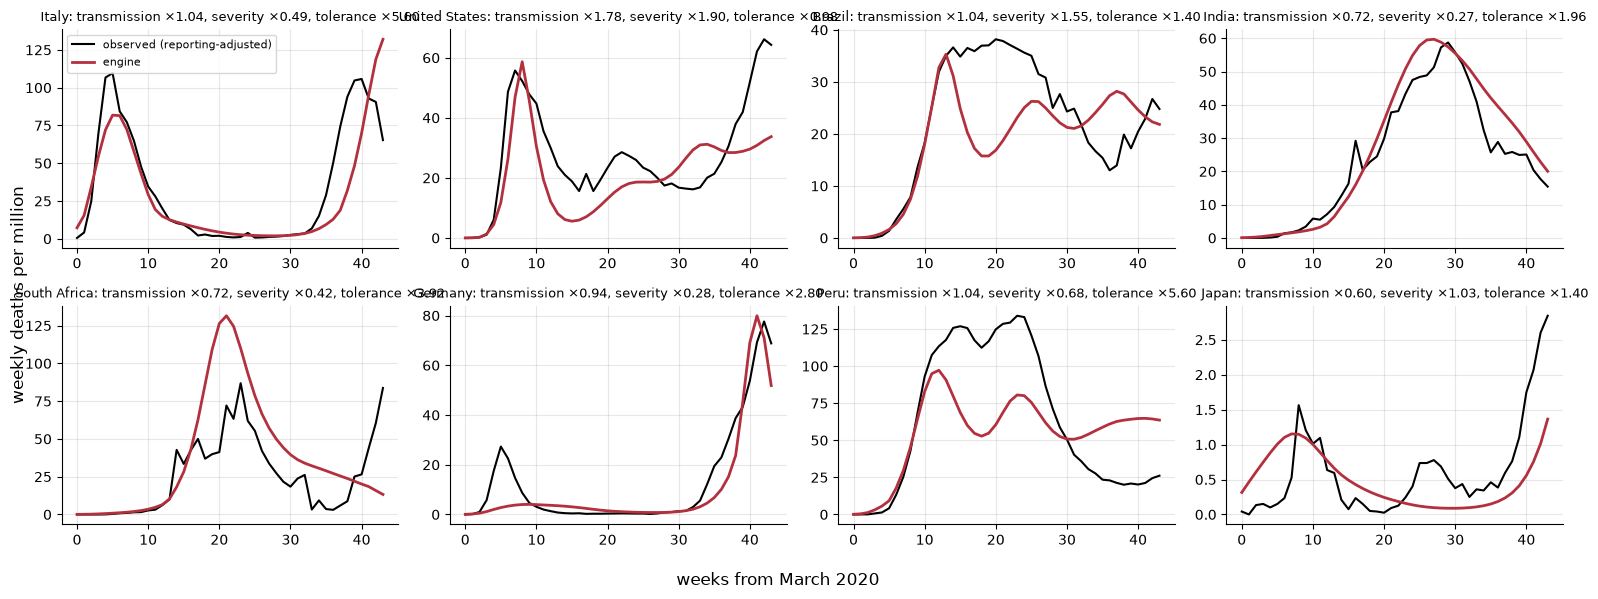

In [4]:
fits = pd.read_parquet(SIM_CALIBRATION_PATH)
examples = [c for c in ["ITA", "USA", "BRA", "IND", "ZAF", "DEU", "PER", "JPN"] if c in set(fits.iso_code)]
fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for ax, iso in zip(axes.flat, examples):
    f = fits[fits.iso_code == iso]
    pm = 1e6 / f.population.iloc[0]
    ax.plot(f.week, f.observed_deaths * pm, color="black", lw=1.5, label="observed (reporting-adjusted)")
    ax.plot(f.week, f.fitted_deaths * pm, color="#b3303e", lw=2, label="engine")
    p = f.iloc[0]
    ax.set_title(f"{names[iso]}: transmission ×{p.transmission:.2f}, severity ×{p.severity:.2f}, tolerance ×{p.awareness:.2f}", fontsize=9)
axes.flat[0].legend(fontsize=8); fig.supxlabel("weeks from March 2020"); fig.supylabel("weekly deaths per million"); fig.tight_layout()

## M3: what explains a country's transmission, severity and tolerance of deaths?

Each country also gets its own awareness threshold (stage 2 of the calibration). With one shared threshold, countries that sustained high death rates (the US, Western Europe) could only be fitted with inflated fatality rates. Ridge regression of the calibrated log multipliers on standardised country features. Out-of-fold R² shows how much of the variation the features capture; gradient boosting is the non-linear benchmark under the same folds.

Median fit error (log scale): one shared threshold 0.69, per-country thresholds 0.535; awareness multipliers p10-p90 [0.122, 5.6]


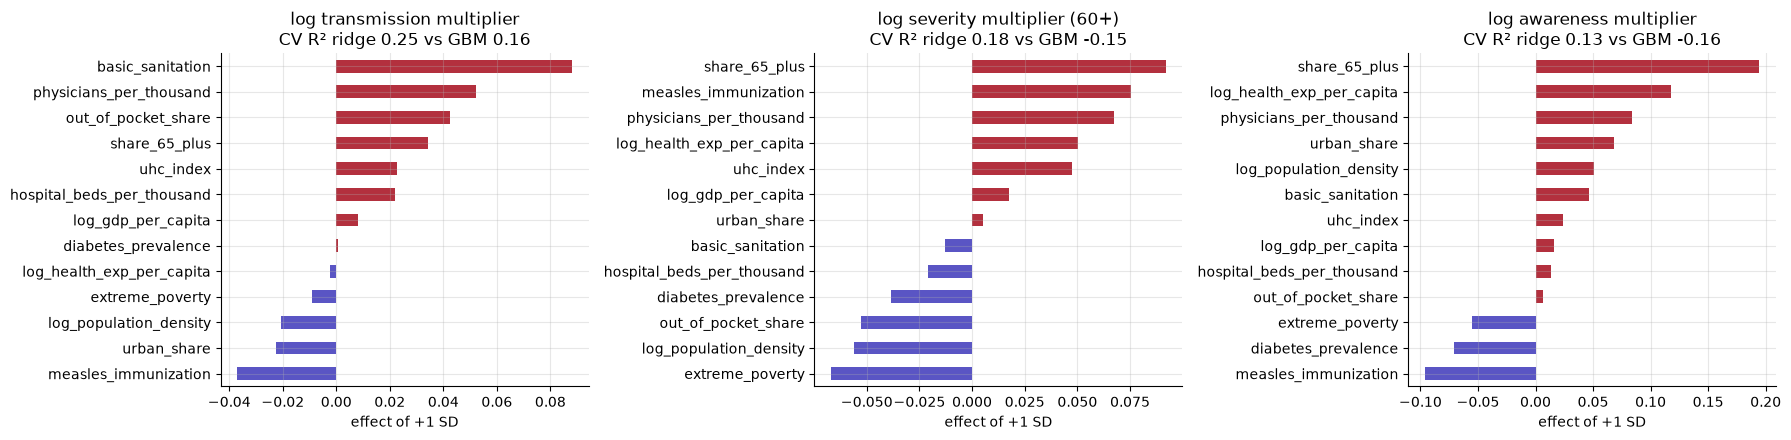

In [5]:
print(f"Median fit error (log scale): one shared threshold {cal['stage1_median_fit_rmse_log']}, per-country thresholds {cal['median_fit_rmse_log']}; "
      f"awareness multipliers p10-p90 {cal['awareness_multiplier_range_p10_p90']}")
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
for ax, key, title in zip(axes, ["transmission", "severity", "awareness"], ["log transmission multiplier", "log severity multiplier (60+)", "log awareness multiplier"]):
    coef = pd.Series(model["models"][key]["coef"]).sort_values()
    coef.plot.barh(ax=ax, color=["#5a55c4" if v < 0 else "#b3303e" for v in coef])
    m3 = metrics[f"m3_{key}"]
    ax.set(title=f"{title}\nCV R² ridge {m3['cv_r2_ridge']:.2f} vs GBM {m3['cv_r2_gbm']:.2f}", xlabel="effect of +1 SD")
fig.tight_layout()

## Validation: does the simulator predict data it never saw?

Two out-of-sample tests, scored as mean absolute error in weekly deaths per million.

* **Temporal holdout**: calibrate each country on March–July 2020, then replay August–December with its observed stringency. Compared with persistence (the last four weeks continue) and three ablations: no lockdown effect, no awareness and no seasonality.
* **Cross-country hindcast**: predict a country's 2020 from its features alone (M3 trained without it), against the continent-average curve and the curve of its nearest analog.

mae_weekly_deaths_pm  \
temporal_holdout       no_awareness                         99.195   
                       no_policy_effect                     22.236   
                       no_seasonality                       21.863   
                       persistence                          16.724   
                       simulator                            23.481   
cross_country_hindcast continent_average                    11.968   
                       nearest_analog                       13.628   
                       simulator                            19.210   
                       simulator_no_features                33.133   

                                              median_country_mae   wape  \
temporal_holdout       no_awareness                       39.080  5.099   
                       no_policy_effect                   15.605  1.143   
                       no_seasonality                     16.860  1.124   
                       persistence                        10.778  0.860   
                       simulator                          17.389  1.207   
cross_country_hindcast continent_average                   9.786  0.874   
                       nearest_analog                     11.181  0.996   
                       simulator                          14.720  1.404   
                       simulator_no_features              25.338  2.421   

                                              mae_cumulative_deaths_pm  \
temporal_holdout       no_awareness                             2008.9   
                       no_policy_effect                          415.9   
                       no_seasonality                            382.2   
                       persistence                               307.9   
                       simulator                                 425.6   
cross_country_hindcast continent_average                         355.3   
                       nearest_analog                            444.9   
                       simulator                                 639.8   
                       simulator_no_features                    1296.1   

                                              spearman_cumulative  \
temporal_holdout       no_awareness                         0.319   
                       no_policy_effect                     0.228   
                       no_seasonality                       0.218   
                       persistence                          0.419   
                       simulator                            0.278   
cross_country_hindcast continent_average                    0.536   
                       nearest_analog                       0.439   
                       simulator                            0.046   
                       simulator_no_features               -0.268   

                                              median_peak_week_error  
temporal_holdout       no_awareness                              5.0  
                       no_policy_effect                          4.0  
                       no_seasonality                            7.0  
                       persistence                              14.0  
                       simulator                                 5.0  
cross_country_hindcast continent_average                        10.0  
                       nearest_analog                            7.0  
                       simulator                                 8.0  
                       simulator_no_features                    10.0

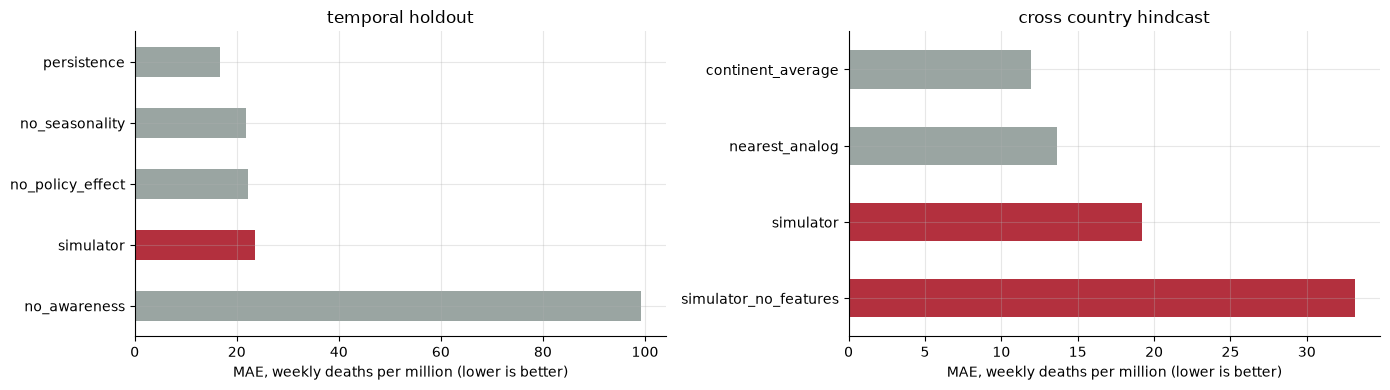

In [6]:
val = metrics["validation"]
table = pd.concat({test: pd.DataFrame(val[test]).T for test in ["temporal_holdout", "cross_country_hindcast"]})
display(table[["mae_weekly_deaths_pm", "median_country_mae", "wape", "mae_cumulative_deaths_pm", "spearman_cumulative", "median_peak_week_error"]])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, test in zip(axes, ["temporal_holdout", "cross_country_hindcast"]):
    s = pd.DataFrame(val[test]).T["mae_weekly_deaths_pm"].sort_values()
    s.plot.barh(ax=ax, color=["#b3303e" if i.startswith("simulator") else "#9aa5a2" for i in s.index])
    ax.invert_yaxis(); ax.set(title=test.replace("_", " "), xlabel="MAE, weekly deaths per million (lower is better)")
fig.tight_layout()

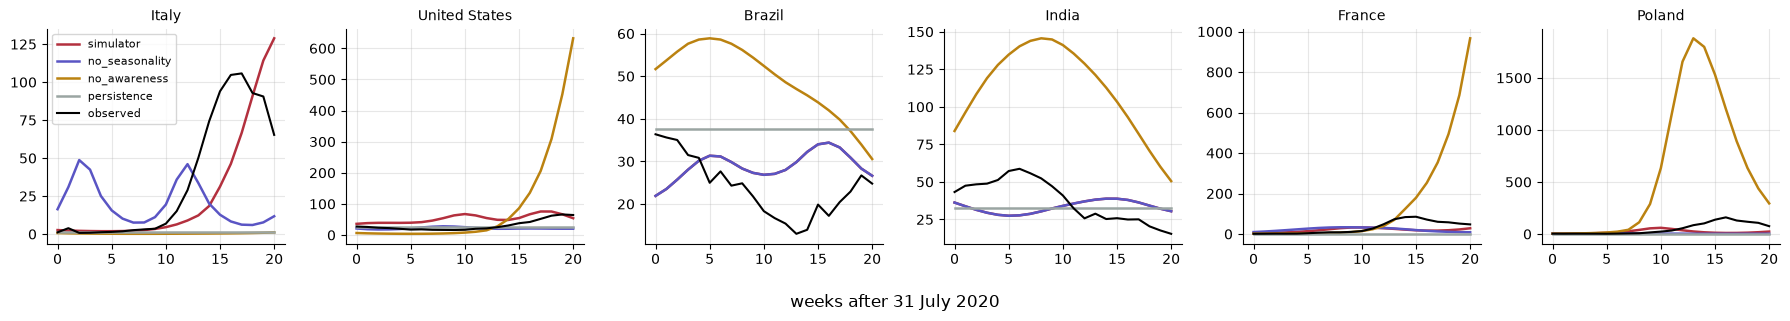

In [7]:
detail = pd.read_parquet(SIM_VALIDATION_PATH)
th = detail[detail.test == "temporal_holdout"]
examples = [c for c in ["ITA", "USA", "BRA", "IND", "FRA", "POL"] if c in set(th.iso_code)]
fig, axes = plt.subplots(1, len(examples), figsize=(18, 3.2))
for ax, iso in zip(axes, examples):
    d = th[th.iso_code == iso]
    for method, color in [("simulator", "#b3303e"), ("no_seasonality", "#5a55c4"), ("no_awareness", "#bb8210"), ("persistence", "#9aa5a2")]:
        s = d[d.method == method]
        ax.plot(s.week, s.predicted_pm, color=color, lw=1.8, label=method)
    obs = d[d.method == "simulator"]
    ax.plot(obs.week, obs.observed_pm, color="black", lw=1.5, label="observed")
    ax.set_title(names[iso], fontsize=10)
axes[0].legend(fontsize=8); fig.supxlabel("weeks after 31 July 2020"); fig.tight_layout()

**Reading the results**

* **Awareness is essential.** A plain SEIR model's out-of-time error is about five times larger. Without behaviour feedback, epidemics overshoot.
* **Country features carry real information.** Replaying a country from its features alone roughly halves the error of the same engine with no features.
* **Seasonality fits 2020 much better, but doesn't forecast better.** It cuts the calibration misfit by a quarter and times the autumn peak better, but leaves out-of-time error about where it was.
* **The lockdown effect barely changes out-of-time accuracy** once awareness is modelled. Behaviour tracked deaths with or without mandates, so this test can't sharply separate the two. The simulator still uses the calibrated effect, because it best explains 2020 across 137 countries, and the uncertainty bands carry its range.
* **The simulator is not a forecaster.** It doesn't beat simple statistical baselines at predicting death counts: persistence in time, the continent average across countries.

This is why the app presents **scenarios** ("if these conditions hold, then…"), not forecasts. That matches the US Scenario Modeling Hub's experience.

## M4 and M5: vaccine rollout and death reporting

Vaccine curves fitted for 157 countries (median RMSE 0.016). CV R²: acceptance 0.31, speed 0.48.
Reporting: 86 countries with usable excess mortality; median 67% of deaths reported; CV R² 0.23.


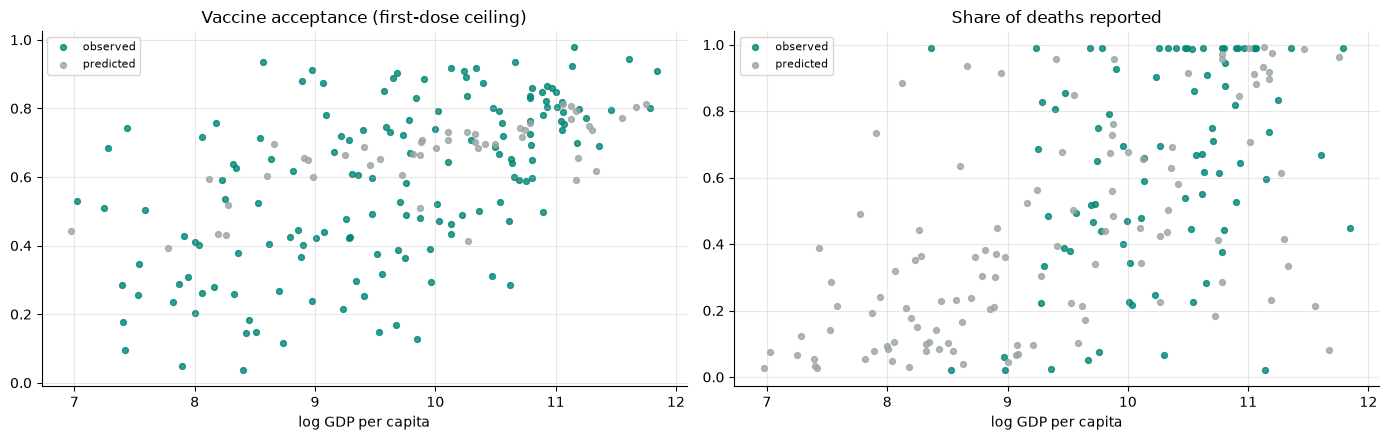

In [8]:
vac = metrics["m4_vaccine_rollout"]; rep = metrics["m5_reporting"]
print(f"Vaccine curves fitted for {vac['countries_fitted']} countries (median RMSE {vac['median_curve_rmse']:.3f}). "
      f"CV R²: acceptance {vac['ceiling']['cv_r2_ridge']:.2f}, speed {vac['speed']['cv_r2_ridge']:.2f}.")
print(f"Reporting: {rep['n']} countries with usable excess mortality; median {rep['median_observed']:.0%} of deaths reported; CV R² {rep['cv_r2_ridge']:.2f}.")
countries = pd.DataFrame([{"iso": c["iso"], "continent": c["continent"], **{k: v["value"] for k, v in c["learned"].items()},
                           **{f"{k}_source": v["source"] for k, v in c["learned"].items()}} for c in model["countries"]]).set_index("iso")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, col, title in zip(axes, ["vaccine_acceptance", "reporting"], ["Vaccine acceptance (first-dose ceiling)", "Share of deaths reported"]):
    for source, color in [("observed", "#008675"), ("predicted", "#9aa5a2")]:
        sub = countries[countries[f"{col}_source"] == source]
        ax.scatter(np.log(profile.loc[sub.index, "gdp_per_capita"]), sub[col], s=18, color=color, label=source, alpha=0.8)
    ax.set(title=title, xlabel="log GDP per capita"); ax.legend(fontsize=8)
fig.tight_layout()

## M6: classifying wave severity

Each historical wave (a peak in smoothed weekly deaths per million) is labelled by its peak quartile and described by what was known at its start: country features, stringency in its first four weeks, vaccination coverage, earlier deaths and the variant era. Cross-validation holds out whole countries.

,accuracy,macro_f1,roc_auc_ovr,log_loss
logistic,0.556,0.552,0.794,1.046
gradient_boosting,0.559,0.557,0.806,1.275
era_only,0.346,0.321,0.530,1.364
class_frequencies,0.252,0.101,0.500,1.386


,pred low,pred moderate,pred high,pred severe
true low,71,20,3,1
true moderate,23,42,18,12
true high,7,19,39,30
true severe,1,12,23,60


[Text(0.5, 1.0, 'Reliability of P(severe)'), (0.0, 1.0), (0.0, 1.0)]

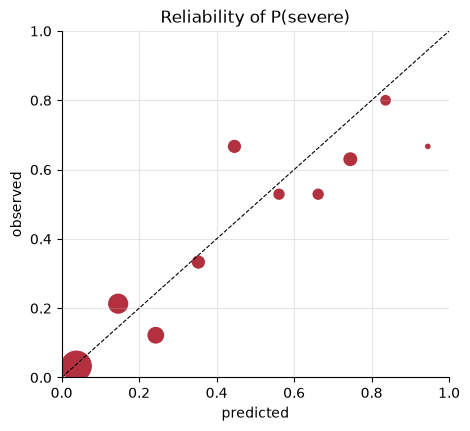

In [9]:
m6 = metrics["m6_wave_classifier"]
display(pd.DataFrame(m6["scores"]).T)
classes = model["models"]["waves"]["classes"]
cm = pd.DataFrame(m6["confusion_matrix_logistic"], index=[f"true {c}" for c in classes], columns=[f"pred {c}" for c in classes])
display(cm)
calib = pd.DataFrame(m6["calibration_severe_logistic"])
ax = calib.plot.scatter(x="predicted", y="observed", s=calib["n"] * 3, color="#b3303e", figsize=(5, 4.5))
ax.plot([0, 1], [0, 1], color="black", lw=0.8, ls="--"); ax.set(title="Reliability of P(severe)", xlim=(0, 1), ylim=(0, 1))

## M7: country archetypes

Standardised country features clustered with k-means (k chosen by silhouette) and projected onto two principal components. The simulator uses distances in this space to name a scenario's closest real countries and to flag a configured country as "unlike any real country".

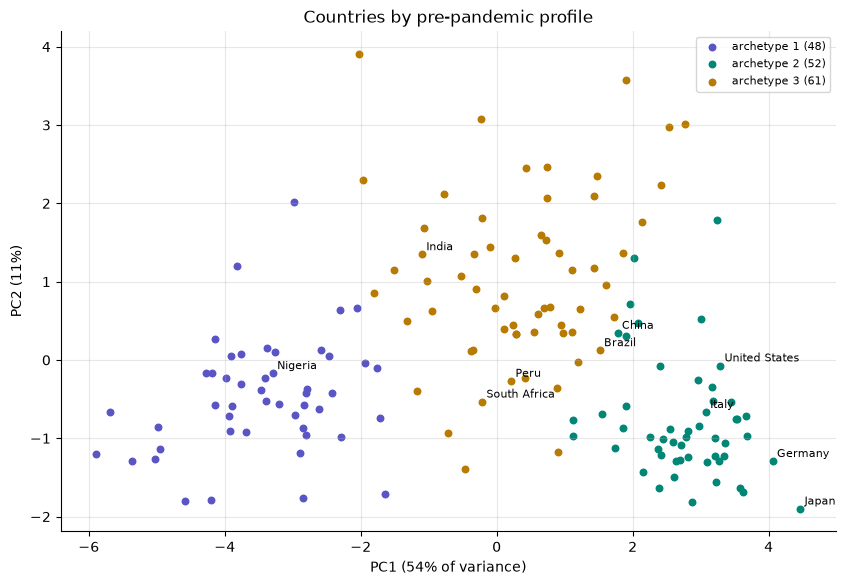

In [10]:
arch = pd.DataFrame([{"iso": c["iso"], "name": c["name"], **c["archetype"]} for c in model["countries"]]).set_index("iso")
arch = arch[arch.index.isin(profile.index[profile.population >= 1e6])]
fig, ax = plt.subplots(figsize=(10, 6.5))
for k, color in zip(sorted(arch.cluster.unique()), ["#5a55c4", "#008675", "#b87a00", "#b3303e", "#85918e", "#172422"]):
    sub = arch[arch.cluster == k]
    ax.scatter(sub.pc1, sub.pc2, s=22, color=color, label=f"archetype {k + 1} ({len(sub)})")
for iso in ["USA", "IND", "NGA", "JPN", "BRA", "DEU", "CHN", "PER", "ZAF", "ITA"]:
    if iso in arch.index:
        ax.annotate(arch.at[iso, "name"], (arch.at[iso, "pc1"], arch.at[iso, "pc2"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
ev = metrics["m7_archetypes"]["pca_explained_variance"]
ax.set(xlabel=f"PC1 ({ev[0]:.0%} of variance)", ylabel=f"PC2 ({ev[1]:.0%})", title="Countries by pre-pandemic profile"); ax.legend(fontsize=8)

## Limitations

* **Scenarios, not forecasts.** Out of sample the simulator doesn't beat simple statistical baselines at predicting death counts (above). Its job is comparing what-ifs under stated assumptions.
* **Learned from one pandemic.** Country multipliers come from SARS-CoV-2 in 2020. Applying them to other pathogens is an extrapolation, and the app says so.
* **Awareness is one mechanism, fitted per country.** A first version gave every country the same threshold. It capped the highest peaks and inflated rich countries' fatality rates to 2–3× published estimates (the US at 2.3%), so each country now has its own threshold. Its spread is wide, and deaths alone still can't fully pin it down.
* **Homogeneous mixing** between age groups; no spatial spread.
* **Identifiability.** Deaths alone can't fully separate how many people were infected from how deadly infection was, so transmission and severity multipliers trade off. Priors keep them near 1, and the uncertainty bands reflect the trade-off.
* **ICU capacity, hospital overload and some preset parameters are assumptions**, marked in the app.